In [1]:
import json
from pathlib import Path
from math import sqrt
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
import hdbscan
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
import torch
import torch.nn as nn
from sklearn.cluster import KMeans
from scipy.signal import savgol_filter, find_peaks
from scipy.stats import mode
from collections import defaultdict
from sklearn.preprocessing import normalize
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from scipy.signal import savgol_filter, find_peaks
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import normalize
import cv2
import os
from collections import defaultdict

In [2]:
#!pip install xarray
#!pip install umap-learn

In [3]:
"""
load_annotations.py
────────────────────
Loads rat_movement.json and builds a numpy array of shape:
  (n_frames, n_bodyparts, n_coordinates)  →  e.g. (550, 7, 2)

Also creates a labelled xarray DataArray for convenient named-axis access.

Requirements:
  pip install numpy xarray
"""

import json
import numpy as np
import xarray as xr

# ── load JSON ─────────────────────────────────────────────────────────────────
with open("rat_movement_large.json") as f:
    data = json.load(f)

annotations = data["annotations"]

# ── extract ordered axes ──────────────────────────────────────────────────────
n_frames    = len(annotations)
frame_ids   = [str(i) for i in range(n_frames)]           # "0", "1", …
body_parts  = list(annotations["0"].keys())               # preserves insertion order
n_bodyparts = len(body_parts)
coords_axes = ["x", "y"]
n_coords    = len(coords_axes)

# ── build numpy array  (n_frames, n_bodyparts, n_coordinates) ─────────────────
arr = np.zeros((n_frames, n_bodyparts, n_coords), dtype=np.float32)

for fi, fid in enumerate(frame_ids):
    for bi, bp in enumerate(body_parts):
        arr[fi, bi, :] = annotations[fid][bp]   # [x, y]

print("numpy array shape:", arr.shape)           # (550, 7, 2)
print("dtype           :", arr.dtype)

# ── wrap in xarray for labelled access (optional but handy) ───────────────────
da = xr.DataArray(
    arr,
    dims=["frame", "bodypart", "coord"],
    coords={
        "frame":    np.arange(n_frames),
        "bodypart": body_parts,
        "coord":    coords_axes,
    },
    name="keypoints",
)

print("\nxarray DataArray:\n", da)

# ── example accesses ──────────────────────────────────────────────────────────
# All (x, y) positions of the head across every frame  → shape (n_frames, 2)
head_xy = da.sel(bodypart="head").values
print("\nhead x/y — first 5 frames:\n", head_xy[:5])

# x-coordinate of every body part at frame 0  → shape (n_bodyparts,)
frame0_x = da.sel(frame=0, coord="x").values
print("\nframe 0 — x coords per body part:")
for bp, x in zip(body_parts, frame0_x):
    print(f"  {bp:20s} {x:.1f}")

numpy array shape: (88000, 7, 2)
dtype           : float32

xarray DataArray:
 <xarray.DataArray 'keypoints' (frame: 88000, bodypart: 7, coord: 2)> Size: 5MB
array([[[323., 300.],
        [306., 300.],
        [285., 300.],
        ...,
        [305., 310.],
        [308., 290.],
        [283., 311.]],

       [[330., 300.],
        [312., 300.],
        [290., 300.],
        ...,
        [325., 310.],
        [301., 289.],
        [305., 311.]],

       [[336., 301.],
        [318., 300.],
        [296., 300.],
        ...,
...
        ...,
        [ 61., 301.],
        [ 38., 290.],
        [ 38., 309.]],

       [[ 48., 296.],
        [ 49., 300.],
        [ 26., 300.],
        ...,
        [ 35., 300.],
        [ 39., 289.],
        [ 38., 310.]],

       [[ 49., 303.],
        [ 49., 300.],
        [ 27., 300.],
        ...,
        [ 57., 300.],
        [ 38., 290.],
        [ 38., 310.]]], shape=(88000, 7, 2), dtype=float32)
Coordinates:
  * frame     (frame) int64 704kB 0 1 2 3

In [4]:
def preprocess(raw_sequence):
    # compute speed from raw arena movement BEFORE centering
    center_raw  = raw_sequence[:, 1, :]                        # (T, 2)
    center_diff = np.diff(center_raw, axis=0)                  # (T-1, 2)
    center_diff = np.concatenate([center_diff[:1], center_diff], axis=0)  # (T, 2)
    speed       = np.linalg.norm(center_diff, axis=-1)         # (T,)
    print(f"Speed stats: mean={speed.mean():.3f}, std={speed.std():.3f}, max={speed.max():.3f}")
    speed       = np.tile(speed[:, None, None], (1, 7, 1))     # (T, 7, 1)

    # center and heading-align
    centroid = raw_sequence[:, 1:2, :]
    centered = raw_sequence - centroid

    head  = centered[:, 0, :]
    angle = np.arctan2(head[:, 1], head[:, 0])
    cos_a = np.cos(-angle)
    sin_a = np.sin(-angle)

    x = centered[:, :, 0]
    y = centered[:, :, 1]
    x_rot = x * cos_a[:, None] - y * sin_a[:, None]
    y_rot = x * sin_a[:, None] + y * cos_a[:, None]
    aligned = np.stack([x_rot, y_rot], axis=-1)                # (T, 7, 2)

    # velocity of aligned joints (captures gait/paw swing)
    vel = np.diff(aligned, axis=0)
    vel = np.concatenate([vel[:1], vel], axis=0)               # (T, 7, 2)

    # angular velocity (captures turning)
    ang_vel = np.diff(angle, axis=0)
    ang_vel = np.concatenate([ang_vel[:1], ang_vel])
    ang_vel = np.tile(ang_vel[:, None, None], (1, 7, 1))       # (T, 7, 1)

    return np.concatenate([aligned, vel, ang_vel, speed], axis=-1)  # (T, 7, 6)

raw_processed = preprocess(da.values)


raw_processed = preprocess(da.values)

Speed stats: mean=5.453, std=37.165, max=597.001
Speed stats: mean=5.453, std=37.165, max=597.001


In [5]:
n_frames, n_joints, n_coords = raw_processed.shape
da_scaled = np.zeros_like(raw_processed)
scalers = []

for j in range(n_joints):
    joint_scalers = []
    for c in range(n_coords):
        scaler = StandardScaler()
        da_scaled[:, j, c] = scaler.fit_transform(
            raw_processed[:, j, c].reshape(-1, 1)
        ).squeeze()
        joint_scalers.append(scaler)
    scalers.append(joint_scalers)

raw_processed = da_scaled

In [6]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.preprocessing import normalize
from sklearn.cluster import MeanShift, estimate_bandwidth
from sklearn.metrics import silhouette_score
from scipy.signal import savgol_filter, find_peaks
from umap import UMAP

# ============================================================
# MODEL
# ============================================================

class HierarchicalRAE(nn.Module):
    def __init__(self,
                 joint_dim,
                 joint_embed=16,
                 pose_embed=64,
                 hidden_dim=128,
                 latent_dim=30,
                 num_joints=7):
        super().__init__()
        self.num_joints = num_joints

        # --- Encoder ---
        self.joint_encoder = nn.Sequential(
            nn.Linear(joint_dim, joint_embed),
            nn.Tanh(),
            nn.Linear(joint_embed, joint_embed)
        )
        self.pose_encoder = nn.Sequential(
            nn.Linear(num_joints * joint_embed, pose_embed),
            nn.Tanh()
        )
        self.encoder_rnn = nn.LSTM(pose_embed, hidden_dim, batch_first=True)
        self.fc_latent    = nn.Linear(hidden_dim, latent_dim)

        # --- Decoder ---
        self.fc_decode_h  = nn.Linear(latent_dim, hidden_dim)
        self.fc_decode_c  = nn.Linear(latent_dim, hidden_dim)
        self.decoder_rnn  = nn.LSTM(latent_dim, hidden_dim, batch_first=True)
        self.decoder_proj = nn.Linear(hidden_dim, pose_embed)
        self.pose_decoder = nn.Sequential(
            nn.Linear(pose_embed, num_joints * joint_embed),
            nn.Tanh()
        )
        self.joint_decoder = nn.Linear(joint_embed, joint_dim)

        self._init_weights()

    def _init_weights(self):
        nn.init.xavier_uniform_(self.fc_decode_h.weight, gain=2.0)
        nn.init.xavier_uniform_(self.fc_decode_c.weight, gain=2.0)
        nn.init.constant_(self.fc_decode_h.bias, 0.0)
        nn.init.constant_(self.fc_decode_c.bias, 0.0)
        nn.init.xavier_uniform_(self.fc_latent.weight, gain=2.0)
        nn.init.constant_(self.fc_latent.bias, 0.0)

        for name, param in self.decoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param, gain=2.0)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param, gain=2.0)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for name, param in self.encoder_rnn.named_parameters():
            if 'weight_ih' in name:
                nn.init.xavier_uniform_(param)
            elif 'weight_hh' in name:
                nn.init.orthogonal_(param)
            elif 'bias' in name:
                nn.init.zeros_(param)

        for module in [self.joint_encoder, self.pose_encoder,
                       self.pose_decoder, self.joint_decoder,
                       self.decoder_proj]:
            if isinstance(module, nn.Sequential):
                for layer in module:
                    if isinstance(layer, nn.Linear):
                        nn.init.xavier_uniform_(layer.weight)
                        nn.init.zeros_(layer.bias)
            elif isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def encode(self, x, lengths=None):
        from torch.nn.utils.rnn import pack_padded_sequence
        B, T, J, C = x.shape

        x_flat = x.view(B * T * J, C)
        x_flat = self.joint_encoder(x_flat)
        x_enc  = x_flat.view(B, T, J, -1)
        x_enc  = x_enc.view(B, T, -1)
        x_enc  = self.pose_encoder(x_enc)

        if lengths is not None:
            packed = pack_padded_sequence(
                x_enc, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            _, (h, _) = self.encoder_rnn(packed)
        else:
            _, (h, _) = self.encoder_rnn(x_enc)

        z = self.fc_latent(h[-1])
        return z

    def decode(self, z, T):
        B   = z.shape[0]
        h   = self.fc_decode_h(z).unsqueeze(0)
        c   = self.fc_decode_c(z).unsqueeze(0)
        inp = z.unsqueeze(1).repeat(1, T, 1)
        dec, _ = self.decoder_rnn(inp, (h, c))
        dec    = self.decoder_proj(dec)
        return dec

    def forward(self, x, lengths=None):
        B, T, J, C = x.shape
        z   = self.encode(x, lengths)
        dec = self.decode(z, T)
        dec = self.pose_decoder(dec)
        dec = dec.view(B, T, J, -1)
        dec = dec.view(B * T * J, -1)
        dec = self.joint_decoder(dec)
        dec = dec.view(B, T, J, C)
        return dec, z


# ============================================================
# COLLATE FUNCTION
# ============================================================

def collate_variable_length(batch):
    lengths = [x.shape[0] for x in batch]
    B       = len(batch)
    T_max   = max(lengths)
    J, C    = batch[0].shape[1], batch[0].shape[2]

    padded = torch.zeros(B, T_max, J, C)
    for i, x in enumerate(batch):
        padded[i, :lengths[i]] = x

    return padded, torch.tensor(lengths, dtype=torch.long)


# ============================================================
# EXTRACT WINDOWS (fixed-size, Stage 1 only)
# ============================================================

def extract_nonoverlapping_windows(raw_sequence, window_size):
    n_frames = len(raw_sequence)
    windows  = []
    for start in range(0, n_frames - window_size, window_size):
        windows.append(raw_sequence[start:start + window_size])
    windows = np.array(windows)
    print(f"Extracted {len(windows)} non-overlapping windows")
    print(f"Coverage: {len(windows) * window_size}/{n_frames} frames "
          f"({100 * len(windows) * window_size / n_frames:.1f}%)")
    return windows


# ============================================================
# STAGE 1: Train on fixed-size windows
# ============================================================

def train_on_fixed_windows(raw_sequence, window_size=30,
                            epochs=300, batch_size=32,
                            lr=1e-4, device='cpu'):
    windows  = extract_nonoverlapping_windows(raw_sequence, window_size)
    X_tensor = torch.tensor(windows, dtype=torch.float32)

    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    from torch.utils.data import TensorDataset
    dataset = TensorDataset(X_tensor)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model     = HierarchicalRAE(latent_dim=16, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()

    lossgraph = []
    print("Training on fixed windows...")
    for epoch in range(epochs):
        total_loss = 0
        for (batch,) in loader:
            batch    = batch.to(device)
            recon, _ = model(batch)
            loss     = loss_fn(recon, batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}")

    return model, lossgraph


# ============================================================
# STAGE 4b: Retrain on variable-length windows
# ============================================================

def train_on_variable_windows(raw_sequence, windows,
                               epochs=300, batch_size=32,
                               lr=1e-4, device='cpu'):
    n_joints  = raw_sequence.shape[1]
    joint_dim = raw_sequence.shape[2]

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=True,
                        collate_fn=collate_variable_length)

    model     = HierarchicalRAE(latent_dim=16, joint_dim=joint_dim,
                                num_joints=n_joints).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn   = nn.MSELoss()

    lossgraph = []
    print("Retraining on variable-length windows...")
    for epoch in range(epochs):
        total_loss = 0
        for padded, lengths in loader:
            padded   = padded.to(device)
            recon, _ = model(padded, lengths=lengths)

            # only compute loss on real frames, not padding
            loss = torch.tensor(0.0, device=device)
            for i, l in enumerate(lengths):
                loss = loss + loss_fn(recon[i, :l], padded[i, :l])
            loss = loss / len(lengths)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg = total_loss / len(loader)
        lossgraph.append(avg)
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs} — Loss: {avg:.6f}")

    return model, lossgraph


# ============================================================
# STAGE 2: Compute reconstruction loss signal
# ============================================================

def compute_frame_loss(model, raw_sequence, window_size,
                        stride=5, device='cpu'):
    model.eval()
    losses    = []
    positions = []

    raw_tensor = torch.tensor(raw_sequence, dtype=torch.float32, device=device)
    loss_fn    = nn.MSELoss()

    with torch.no_grad():
        for start in range(0, len(raw_sequence) - window_size, stride):
            window   = raw_tensor[start:start + window_size].unsqueeze(0)
            recon, _ = model(window)
            loss     = loss_fn(recon, window).item()
            losses.append(loss)
            positions.append(start + window_size // 2)

    positions = np.array(positions)
    losses    = np.array(losses)
    print(f"Computed loss at {len(losses)} positions")
    print(f"Loss stats — mean: {losses.mean():.4f}, "
          f"std: {losses.std():.4f}, max: {losses.max():.4f}")
    return positions, losses


# ============================================================
# STAGE 3: Detect transitions
# ============================================================

def find_transitions(positions, losses,
                      percentile=70, smoothing=5,
                      min_distance=3, fps=30):
    if len(losses) < smoothing:
        smoothing = max(3, len(losses) // 2)
        if smoothing % 2 == 0:
            smoothing += 1

    smoothed  = savgol_filter(losses, window_length=smoothing, polyorder=2)
    threshold = np.percentile(smoothed, percentile)
    peaks, _  = find_peaks(smoothed, height=threshold, distance=min_distance)
    transition_frames = positions[peaks]

    if len(transition_frames) > 1:
        intervals = np.diff(transition_frames)
        mean_bout = np.mean(intervals) / fps
        print(f"Found {len(transition_frames)} transitions")
        print(f"Mean bout duration: {mean_bout:.2f}s")
        if mean_bout < 1:
            print("WARNING: bouts too short — raise percentile or min_distance")
        elif mean_bout > 15:
            print("WARNING: bouts too long — lower percentile")
        else:
            print("Bout duration looks plausible")

    return transition_frames, smoothed


# ============================================================
# STAGE 4: Variable-length windows from segments
# ============================================================

def create_windows_from_transitions(raw_sequence, transition_frames,
                                     min_segment_frames=15,
                                     max_segment_frames=300):
    n_frames   = len(raw_sequence)
    boundaries = np.unique(
        np.concatenate([[0], transition_frames, [n_frames]])
    ).astype(int)

    all_windows   = []
    window_labels = []

    for seg_idx in range(len(boundaries) - 1):
        seg_start = boundaries[seg_idx]
        seg_end   = boundaries[seg_idx + 1]
        seg_len   = seg_end - seg_start

        if seg_len < min_segment_frames:
            continue

        segment = raw_sequence[seg_start:seg_end]

        for start in range(0, seg_len, max_segment_frames):
            chunk = segment[start:start + max_segment_frames]
            if len(chunk) < min_segment_frames:
                continue
            all_windows.append(chunk)
            window_labels.append(seg_idx)

    lengths = [len(w) for w in all_windows]
    print(f"Created {len(all_windows)} variable-length windows from "
          f"{len(boundaries) - 1} segments")
    print(f"Window lengths — min: {min(lengths)}, "
          f"max: {max(lengths)}, mean: {np.mean(lengths):.1f}")

    return all_windows, np.array(window_labels)


# ============================================================
# STAGE 5: Encode, UMAP, cluster
# ============================================================

def encode_and_cluster(model, windows, batch_size=32,
                        device='cpu', quantile=0.1,
                        umap_neighbors=30, umap_min_dist=0.1):
    model.eval()
    all_latents = []

    tensor_list = [torch.tensor(w, dtype=torch.float32) for w in windows]
    loader = DataLoader(tensor_list, batch_size=batch_size, shuffle=False,
                        collate_fn=collate_variable_length)

    with torch.no_grad():
        for padded, lengths in loader:
            padded = padded.to(device)
            _, z   = model(padded, lengths=lengths)
            all_latents.append(z.cpu().numpy())

    all_latents = np.concatenate(all_latents, axis=0)  # (N, 16)
    print(f"Latents shape: {all_latents.shape}")

    # UMAP: 16D → 2D
    print("Running UMAP...")
    reducer    = UMAP(n_components=2, n_neighbors=umap_neighbors,
                      min_dist=umap_min_dist, metric='cosine',
                      random_state=42)
    latents_2d = reducer.fit_transform(all_latents)     # (N, 2)
    print(f"UMAP done. Shape: {latents_2d.shape}")

    # MeanShift on 2D UMAP embedding
    normed    = normalize(latents_2d, norm='l2')
    bandwidth = estimate_bandwidth(normed, quantile=quantile)
    print(f"Estimated bandwidth: {bandwidth:.4f}")

    ms     = MeanShift(bandwidth=bandwidth, bin_seeding=True)
    ms.fit(normed)
    labels = ms.labels_

    n_clusters = len(np.unique(labels))
    print(f"Found {n_clusters} clusters")
    print(f"Cluster sizes: {np.bincount(labels)}")

    if n_clusters > 1:
        dist_matrix = np.clip(1 - np.dot(normed, normed.T), 0, 2)
        sil = silhouette_score(dist_matrix, labels, metric='precomputed')
        print(f"Silhouette score: {sil:.4f}")

    return all_latents, latents_2d, labels, ms


# ============================================================
# FULL TWO-PASS PIPELINE
# ============================================================

def run_pipeline_test(raw_sequence, window_size, fps,
                      epochs, percentile, quantile,
                      min_segment_frames, max_segment_frames,
                      stride=5, umap_neighbors=30,
                      umap_min_dist=0.1, device='cpu'):

    # ── PASS 1: fixed windows → transition detection ───────────────────
    print("\n" + "="*50)
    print("STAGE 1: Training RAE on fixed windows")
    print("="*50)
    model_stage1, lossgraph_stage1 = train_on_fixed_windows(
        raw_sequence, window_size=window_size,
        epochs=epochs, device=device
    )

    print("\n" + "="*50)
    print("STAGE 2: Computing reconstruction loss signal")
    print("="*50)
    positions, losses = compute_frame_loss(
        model_stage1, raw_sequence, window_size,
        stride=stride, device=device
    )

    print("\n" + "="*50)
    print("STAGE 3: Finding behavioral transitions")
    print("="*50)
    transition_frames, smoothed = find_transitions(
        positions, losses,
        percentile=percentile, fps=fps
    )

    print("\n" + "="*50)
    print("STAGE 4: Creating variable-length behavioral windows")
    print("="*50)
    windows, window_segment_labels = create_windows_from_transitions(
        raw_sequence, transition_frames,
        min_segment_frames=min_segment_frames,
        max_segment_frames=max_segment_frames
    )

    # ── PASS 2: retrain on variable-length windows ─────────────────────
    print("\n" + "="*50)
    print("STAGE 4b: Retraining RAE on variable-length windows")
    print("="*50)
    model_stage2, lossgraph_stage2 = train_on_variable_windows(
        raw_sequence, windows,
        epochs=epochs, device=device
    )

    print("\n" + "="*50)
    print("STAGE 5: Encoding + UMAP + clustering")
    print("="*50)
    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows,
        quantile=quantile,
        umap_neighbors=umap_neighbors,
        umap_min_dist=umap_min_dist,
        device=device
    )

    return {
        'model':                 model_stage2,
        'model_stage1':          model_stage1,
        'latents':               latents,        # (N, 16) — raw high-dim latents
        'latents_2d':            latents_2d,     # (N, 2)  — UMAP projection
        'cluster_labels':        cluster_labels,
        'transition_frames':     transition_frames,
        'windows':               windows,
        'window_segment_labels': window_segment_labels,
        'losses':                losses,
        'positions':             positions,
        'lossgraph_stage1':      lossgraph_stage1,
        'lossgraph_stage2':      lossgraph_stage2,
        'smoothed_losses':       smoothed,
    }

In [7]:
# ============================================================
# HYPERPARAMETER TUNING: maximize ARI over percentile & quantile
# ============================================================
import random
import gc
from sklearn.metrics import adjusted_rand_score

MAX_ITER = 20
PERCENTILE_RANGE = (45, 55)
QUANTILE_RANGE = (0.1, 0.2)

# ── Train Stage 1 ONCE (shared across all iterations) ────────
print("="*60)
print("PRE-STEP: Training Stage 1 model (shared across iterations)")
print("="*60)
model_stage1, lossgraph_stage1 = train_on_fixed_windows(
    raw_processed, window_size=30, epochs=300, device='cuda'
)

print("\n" + "="*60)
print("PRE-STEP: Computing reconstruction loss signal (shared)")
print("="*60)
positions, losses = compute_frame_loss(
    model_stage1, raw_processed, window_size=30, stride=5, device='cuda'
)

# ── Random search over (percentile, quantile) ────────────────
rng = random.Random(42)
search_log = []
best_results = None
best_ari = -1

ground_truth_labels_arr = np.load("rat_movement_large_labels.npy", allow_pickle=True)

for iteration in range(1, MAX_ITER + 1):
    percentile = rng.uniform(*PERCENTILE_RANGE)
    quantile = rng.uniform(*QUANTILE_RANGE)
    
    print(f"\n{'='*60}")
    print(f"ITERATION {iteration}/{MAX_ITER}  |  percentile={percentile:.1f}, quantile={quantile:.3f}")
    print(f"{'='*60}")
    
    # Stage 3: transitions
    transition_frames, smoothed = find_transitions(
        positions, losses, percentile=percentile, fps=30
    )
    
    # Stage 4: variable windows
    windows, window_segment_labels = create_windows_from_transitions(
        raw_processed, transition_frames,
        min_segment_frames=30, max_segment_frames=600
    )
    
    # Stage 4b: retrain on variable windows
    model_stage2, lossgraph_stage2 = train_on_variable_windows(
        raw_processed, windows, epochs=300, device='cuda'
    )
    
    # Stage 5: encode + cluster
    latents, latents_2d, cluster_labels, ms_model = encode_and_cluster(
        model_stage2, windows, quantile=quantile,
        umap_neighbors=30, umap_min_dist=0.1, device='cuda'
    )
    
    n_clusters = len(np.unique(cluster_labels))
    
    # Compute ARI for ranking
    boundaries = np.unique(
        np.concatenate([[0], transition_frames, [len(raw_processed)]])
    ).astype(int)
    gt_win = []
    for seg_idx in range(len(boundaries) - 1):
        seg_start, seg_end = boundaries[seg_idx], boundaries[seg_idx + 1]
        seg_len = seg_end - seg_start
        if seg_len < 30:
            continue
        for chunk_start in range(0, seg_len, 600):
            abs_start = seg_start + chunk_start
            abs_end = min(abs_start + 600, seg_end)
            if (abs_end - abs_start) < 30:
                continue
            vals, counts = np.unique(ground_truth_labels_arr[abs_start:abs_end], return_counts=True)
            gt_win.append(vals[np.argmax(counts)])
    gt_win = np.array(gt_win)
    beh_names_unique = np.unique(gt_win)
    beh2idx = {b: i for i, b in enumerate(beh_names_unique)}
    gt_num = np.array([beh2idx[b] for b in gt_win])
    ari = adjusted_rand_score(gt_num, cluster_labels)
    
    log_entry = {
        "iteration": iteration,
        "percentile": round(percentile, 2),
        "quantile": round(quantile, 4),
        "n_clusters": n_clusters,
        "ARI": round(float(ari), 4),
    }
    search_log.append(log_entry)
    print(f"  → {n_clusters} clusters, ARI={ari:.4f}")
    
    # Update best: highest ARI wins
    if ari > best_ari:
        best_ari = ari
        best_results = {
            'model': model_stage2,
            'model_stage1': model_stage1,
            'latents': latents,
            'latents_2d': latents_2d,
            'cluster_labels': cluster_labels,
            'transition_frames': transition_frames,
            'windows': windows,
            'window_segment_labels': window_segment_labels,
            'losses': losses,
            'positions': positions,
            'lossgraph_stage1': lossgraph_stage1,
            'lossgraph_stage2': lossgraph_stage2,
            'smoothed_losses': smoothed,
            '_percentile': percentile,
            '_quantile': quantile,
        }
        print(f"  ** NEW BEST (ARI={ari:.4f}) **")
    
    # Cleanup GPU memory
    del model_stage2, latents, latents_2d, cluster_labels, ms_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ── Summary ─────────────────────────────────────────────────
print(f"\n{'='*60}")
print("HYPERPARAMETER SEARCH COMPLETE")
print(f"{'='*60}")
print(f"\nSearch log:")
for entry in search_log:
    marker = " <-- BEST" if entry['ARI'] == best_ari else ""
    print(f"  Iter {entry['iteration']:2d}: percentile={entry['percentile']:6.1f}, quantile={entry['quantile']:.4f}  →  {entry['n_clusters']} clusters, ARI={entry['ARI']:.4f}{marker}")

print(f"\nBest result: percentile={best_results['_percentile']:.1f}, quantile={best_results['_quantile']:.4f}")
print(f"  Clusters: {len(np.unique(best_results['cluster_labels']))}, ARI: {best_ari:.4f}")

# Set results to best for downstream cells
results = best_results

PRE-STEP: Training Stage 1 model (shared across iterations)
Extracted 2933 non-overlapping windows
Coverage: 87990/88000 frames (100.0%)
Training on fixed windows...
Epoch 10/300 — Loss: 0.711504
Epoch 20/300 — Loss: 0.695327
Epoch 30/300 — Loss: 0.684892
Epoch 40/300 — Loss: 0.462302
Epoch 50/300 — Loss: 0.427336
Epoch 60/300 — Loss: 0.400934
Epoch 70/300 — Loss: 0.388043
Epoch 80/300 — Loss: 0.368783
Epoch 90/300 — Loss: 0.352015
Epoch 100/300 — Loss: 0.328391
Epoch 110/300 — Loss: 0.382890
Epoch 120/300 — Loss: 0.320481
Epoch 130/300 — Loss: 0.304422
Epoch 140/300 — Loss: 0.415599
Epoch 150/300 — Loss: 0.374583
Epoch 160/300 — Loss: 0.299625
Epoch 170/300 — Loss: 0.422328
Epoch 180/300 — Loss: 0.292994
Epoch 190/300 — Loss: 0.381980
Epoch 200/300 — Loss: 0.282455
Epoch 210/300 — Loss: 0.376320
Epoch 220/300 — Loss: 0.280611
Epoch 230/300 — Loss: 0.401120
Epoch 240/300 — Loss: 0.275292
Epoch 250/300 — Loss: 0.410095
Epoch 260/300 — Loss: 0.293160
Epoch 270/300 — Loss: 0.324765
Epoch 

c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (1064, 2)
Estimated bandwidth: 0.1400
Found 7 clusters
Cluster sizes: [252 145 171 180 141 111  64]
Silhouette score: 0.8847
  → 7 clusters, ARI=0.4829
  ** NEW BEST (ARI=0.4829) **

ITERATION 2/20  |  percentile=47.8, quantile=0.122
Found 2017 transitions
Mean bout duration: 1.45s
Bout duration looks plausible
Created 1084 variable-length windows from 2018 segments
Window lengths — min: 30, max: 250, mean: 64.5
Retraining on variable-length windows...
Epoch 10/300 — Loss: 0.753743
Epoch 20/300 — Loss: 0.748617
Epoch 30/300 — Loss: 0.742303
Epoch 40/300 — Loss: 0.736412
Epoch 50/300 — Loss: 0.727155
Epoch 60/300 — Loss: 0.424244
Epoch 70/300 — Loss: 0.402098
Epoch 80/300 — Loss: 0.395056
Epoch 90/300 — Loss: 0.388514
Epoch 100/300 — Loss: 0.385952
Epoch 110/300 — Loss: 0.383294
Epoch 120/300 — Loss: 0.384070
Epoch 130/300 — Loss: 0.381542
Epoch 140/300 — Loss: 0.380386
Epoch 150/300 — Loss: 0.379136
Epoch 160/300 — Loss: 0.395307
Epoch 170/300 — Loss: 0.377541
Epoch 1

c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (1084, 2)
Estimated bandwidth: 0.2951
Found 5 clusters
Cluster sizes: [579 191 117 129  68]
Silhouette score: 0.9251
  → 5 clusters, ARI=0.5669
  ** NEW BEST (ARI=0.5669) **

ITERATION 3/20  |  percentile=52.4, quantile=0.168
Found 1781 transitions
Mean bout duration: 1.64s
Bout duration looks plausible
Created 1042 variable-length windows from 1782 segments
Window lengths — min: 30, max: 405, mean: 70.6
Retraining on variable-length windows...
Epoch 10/300 — Loss: 0.827306
Epoch 20/300 — Loss: 0.822134
Epoch 30/300 — Loss: 0.820712
Epoch 40/300 — Loss: 0.811883
Epoch 50/300 — Loss: 0.806282
Epoch 60/300 — Loss: 0.506116
Epoch 70/300 — Loss: 0.468329
Epoch 80/300 — Loss: 0.461460
Epoch 90/300 — Loss: 0.454349
Epoch 100/300 — Loss: 0.449017
Epoch 110/300 — Loss: 0.448047
Epoch 120/300 — Loss: 0.444715
Epoch 130/300 — Loss: 0.452002
Epoch 140/300 — Loss: 0.441332
Epoch 150/300 — Loss: 0.439950
Epoch 160/300 — Loss: 0.440520
Epoch 170/300 — Loss: 0.438153
Epoch 180/300 —

...

UMAP done. Shape: (1080, 2)
Estimated bandwidth: 0.3846
Found 6 clusters
Cluster sizes: [340 365 125 114  73  63]
Silhouette score: 0.7933
  → 6 clusters, ARI=0.5564

ITERATION 19/20  |  percentile=53.3, quantile=0.162
Found 1731 transitions
Mean bout duration: 1.69s
Bout duration looks plausible
Created 1014 variable-length windows from 1732 segments
Window lengths — min: 30, max: 500, mean: 72.9
Retraining on variable-length windows...
Epoch 10/300 — Loss: 0.840673
Epoch 20/300 — Loss: 0.834986
Epoch 30/300 — Loss: 0.827627
Epoch 40/300 — Loss: 0.818956
Epoch 50/300 — Loss: 0.492132
Epoch 60/300 — Loss: 0.758266
Epoch 70/300 — Loss: 0.457483
Epoch 80/300 — Loss: 0.453469
Epoch 90/300 — Loss: 0.450226
Epoch 100/300 — Loss: 0.449344
Epoch 110/300 — Loss: 0.447387
Epoch 120/300 — Loss: 0.445510
Epoch 130/300 — Loss: 0.446728
Epoch 140/300 — Loss: 0.444826
Epoch 150/300 — Loss: 0.442884
Epoch 160/300 — Loss: 0.442205
Epoch 170/300 — Loss: 0.590021
Epoch 180/300 — Loss: 0.445772
Epoch 190

c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (1014, 2)
Estimated bandwidth: 0.3782
Found 6 clusters
Cluster sizes: [280 257 251 110  72  44]
Silhouette score: 0.8351
  → 6 clusters, ARI=0.7181

ITERATION 20/20  |  percentile=53.6, quantile=0.158
Found 1717 transitions
Mean bout duration: 1.71s
Bout duration looks plausible
Created 1006 variable-length windows from 1718 segments
Window lengths — min: 30, max: 500, mean: 73.7
Retraining on variable-length windows...
Epoch 10/300 — Loss: 0.839093
Epoch 20/300 — Loss: 0.839577
Epoch 30/300 — Loss: 0.832582
Epoch 40/300 — Loss: 0.826332
Epoch 50/300 — Loss: 0.541633
Epoch 60/300 — Loss: 0.478023
Epoch 70/300 — Loss: 0.472241
Epoch 80/300 — Loss: 0.451117
Epoch 90/300 — Loss: 0.451679
Epoch 100/300 — Loss: 0.446958
Epoch 110/300 — Loss: 0.448459
Epoch 120/300 — Loss: 0.447035
Epoch 130/300 — Loss: 0.443813
Epoch 140/300 — Loss: 0.444656
Epoch 150/300 — Loss: 0.444962
Epoch 160/300 — Loss: 0.445770
Epoch 170/300 — Loss: 0.441804
Epoch 180/300 — Loss: 0.440602
Epoch 190

c:\Users\fbai_\anaconda3\envs\condaenv312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (1006, 2)
Estimated bandwidth: 0.2705
Found 6 clusters
Cluster sizes: [495 184 127  63  75  62]
Silhouette score: 0.9232
  → 6 clusters, ARI=0.5240

HYPERPARAMETER SEARCH COMPLETE

Search log:
  Iter  1: percentile=  51.4, quantile=0.1025  →  7 clusters, ARI=0.4829
  Iter  2: percentile=  47.8, quantile=0.1223  →  5 clusters, ARI=0.5669
  Iter  3: percentile=  52.4, quantile=0.1677  →  5 clusters, ARI=0.5730
  Iter  4: percentile=  53.9, quantile=0.1087  →  11 clusters, ARI=0.6784
  Iter  5: percentile=  49.2, quantile=0.1030  →  8 clusters, ARI=0.6581
  Iter  6: percentile=  47.2, quantile=0.1505  →  6 clusters, ARI=0.7999
  Iter  7: percentile=  45.3, quantile=0.1199  →  6 clusters, ARI=0.7249
  Iter  8: percentile=  51.5, quantile=0.1545  →  5 clusters, ARI=0.8376
  Iter  9: percentile=  47.2, quantile=0.1589  →  6 clusters, ARI=0.8363
  Iter 10: percentile=  53.1, quantile=0.1006  →  7 clusters, ARI=0.6321
  Iter 11: percentile=  53.1, quantile=0.1698  →  4 cluste

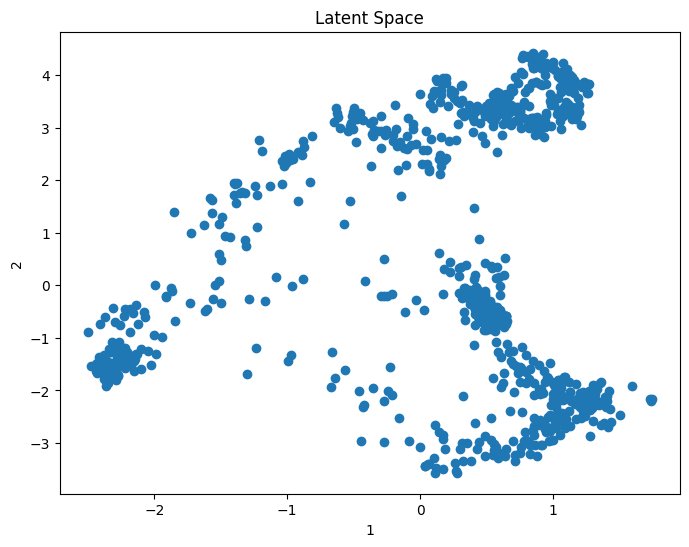

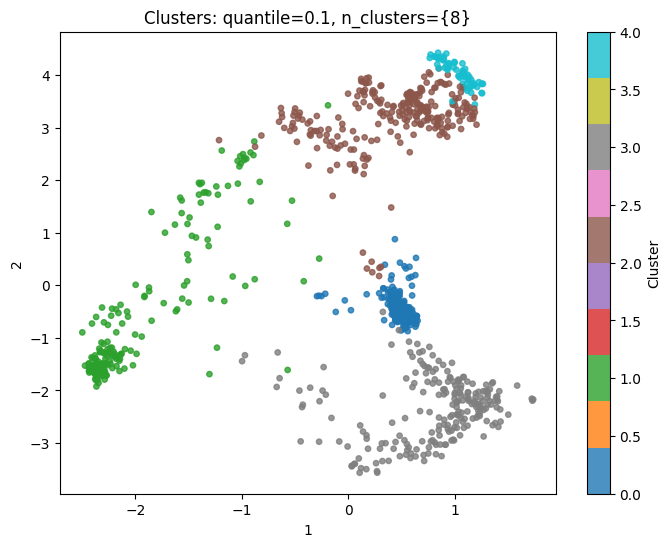

In [8]:
embedded = results['latents']
labels = results['cluster_labels']
plt.figure(figsize=(8, 6))
plt.scatter(embedded[:, 0], embedded[:, 1])
plt.title("Latent Space")
plt.xlabel("1")
plt.ylabel("2")
plt.show()


"""latents = results['latents']
normed  = normalize(latents, norm='l2')
labels = results['cluster_labels']
# UMAP to 2D
reducer   = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.5, random_state=42)
embedded  = reducer.fit_transform(normed)
"""



embedded = results['latents']
labels = results['cluster_labels']
plt.figure(figsize=(8, 6))
plt.scatter(embedded[:, 0], embedded[:, 1],
            c=labels, cmap='tab10', s=15, alpha=0.8)
plt.title("Clusters: quantile=0.1, n_clusters={8}")
plt.colorbar(label='Cluster')
plt.xlabel("1")
plt.ylabel("2")
plt.show()

In [9]:
ground_truth_labels = np.load("rat_movement_large_labels.npy", allow_pickle = True)
raw_sequence = np.load("rat_movement_large.npy")
from scipy.stats import mode

GT labels:      1064
Cluster labels: 1064

ARI:    0.838  (1.0 = perfect, 0 = random)
NMI:    0.866  (1.0 = perfect, 0 = random)

Optimal cluster → behaviour mapping:
  Cluster  2  →  groom           (251/259 = 96.9%)
  Cluster  1  →  rear            (190/190 = 100.0%)
  Cluster  3  →  stretch         (200/226 = 88.5%)
  Cluster  0  →  walk            (325/325 = 100.0%)

Purity: 0.968
Pure windows:   58.6%


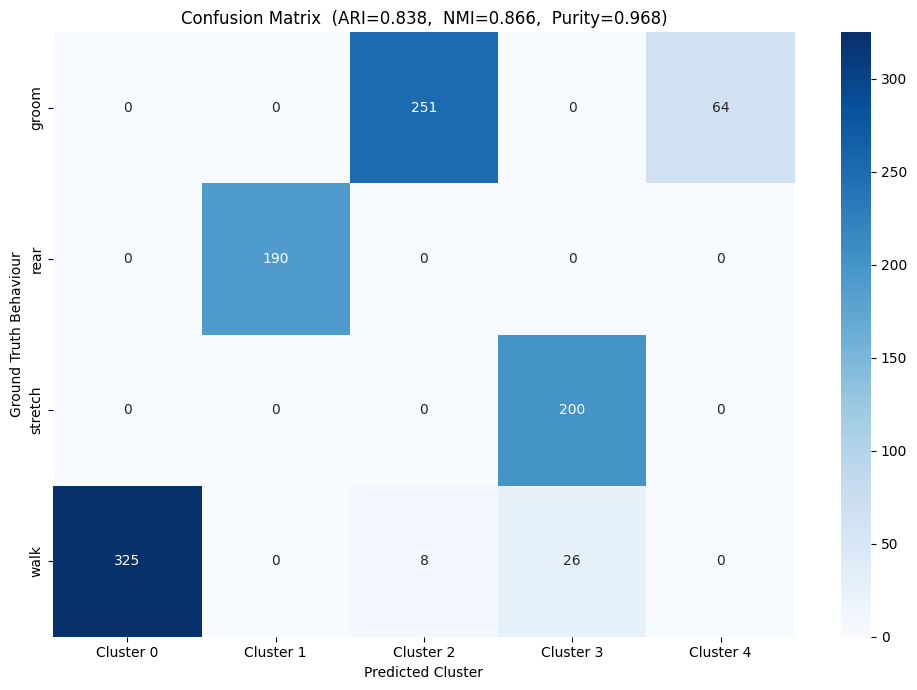

In [10]:
gt_window_labels = []
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.optimize import linear_sum_assignment

# ── Parameters (must match pipeline) ──────────────────────────────────────
min_segment_frames = 30
max_segment_frames = 600

# ── Reconstruct window frame ranges from best results ─────────────────────
n_frames   = len(raw_sequence)
boundaries = np.unique(
    np.concatenate([[0], results['transition_frames'], [n_frames]])
).astype(int)

gt_window_labels = []
for seg_idx in range(len(boundaries) - 1):
    seg_start = boundaries[seg_idx]
    seg_end   = boundaries[seg_idx + 1]
    seg_len   = seg_end - seg_start

    if seg_len < min_segment_frames:
        continue

    for chunk_start in range(0, seg_len, max_segment_frames):
        abs_start = seg_start + chunk_start
        abs_end   = min(abs_start + max_segment_frames, seg_end)
        chunk_len = abs_end - abs_start

        if chunk_len < min_segment_frames:
            continue

        window_frames = ground_truth_labels[abs_start:abs_end]
        values, counts = np.unique(window_frames, return_counts=True)
        majority = values[np.argmax(counts)]
        gt_window_labels.append(majority)

gt_window_labels = np.array(gt_window_labels)
cluster_labels   = results['cluster_labels']

print(f"GT labels:      {len(gt_window_labels)}")
print(f"Cluster labels: {len(cluster_labels)}")
assert len(gt_window_labels) == len(cluster_labels), \
    f"Mismatched: {len(gt_window_labels)} vs {len(cluster_labels)}"

# ── Convert GT strings to numeric for sklearn metrics ─────────────────────
behaviour_names = np.unique(gt_window_labels)
beh_to_idx      = {b: i for i, b in enumerate(behaviour_names)}
gt_numeric      = np.array([beh_to_idx[b] for b in gt_window_labels])

# ── Metrics ────────────────────────────────────────────────────────────────
ari = adjusted_rand_score(gt_numeric, cluster_labels)
nmi = normalized_mutual_info_score(gt_numeric, cluster_labels)
print(f"\nARI:    {ari:.3f}  (1.0 = perfect, 0 = random)")
print(f"NMI:    {nmi:.3f}  (1.0 = perfect, 0 = random)")

# ── Build confusion matrix manually (GT rows, cluster columns) ────────────
cluster_ids = np.unique(cluster_labels)
cm = np.zeros((len(behaviour_names), len(cluster_ids)), dtype=int)

for gt, pred in zip(gt_window_labels, cluster_labels):
    cm[beh_to_idx[gt], pred] += 1

# ── Hungarian matching: optimal cluster → behaviour assignment ─────────────
row_ind, col_ind = linear_sum_assignment(-cm)
print("\nOptimal cluster → behaviour mapping:")
for r, c in zip(row_ind, col_ind):
    total    = cm[:, c].sum()
    correct  = cm[r, c]
    print(f"  Cluster {c:2d}  →  {behaviour_names[r]:14s}  "
          f"({correct}/{total} = {correct/total:.1%})")

# ── Purity ─────────────────────────────────────────────────────────────────
purity = np.sum(np.max(cm, axis=0)) / np.sum(cm)
print(f"\nPurity: {purity:.3f}")

# ── Pure windows ───────────────────────────────────────────────────────────
pure_windows = []
for seg_idx in range(len(boundaries) - 1):
    seg_start = boundaries[seg_idx]
    seg_end   = boundaries[seg_idx + 1]
    seg_len   = seg_end - seg_start

    if seg_len < min_segment_frames:
        continue

    for chunk_start in range(0, seg_len, max_segment_frames):
        abs_start = seg_start + chunk_start
        abs_end   = min(abs_start + max_segment_frames, seg_end)
        if (abs_end - abs_start) < min_segment_frames:
            continue
        n_unique = len(np.unique(ground_truth_labels[abs_start:abs_end]))
        pure_windows.append(n_unique == 1)

print(f"Pure windows:   {np.mean(pure_windows):.1%}")

# ── Plot confusion matrix ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in cluster_ids],
            yticklabels=behaviour_names)
ax.set_xlabel("Predicted Cluster")
ax.set_ylabel("Ground Truth Behaviour")
ax.set_title(f"Confusion Matrix  (ARI={ari:.3f},  NMI={nmi:.3f},  Purity={purity:.3f})")
plt.tight_layout()
plt.show()

Pure windows: 58.6%


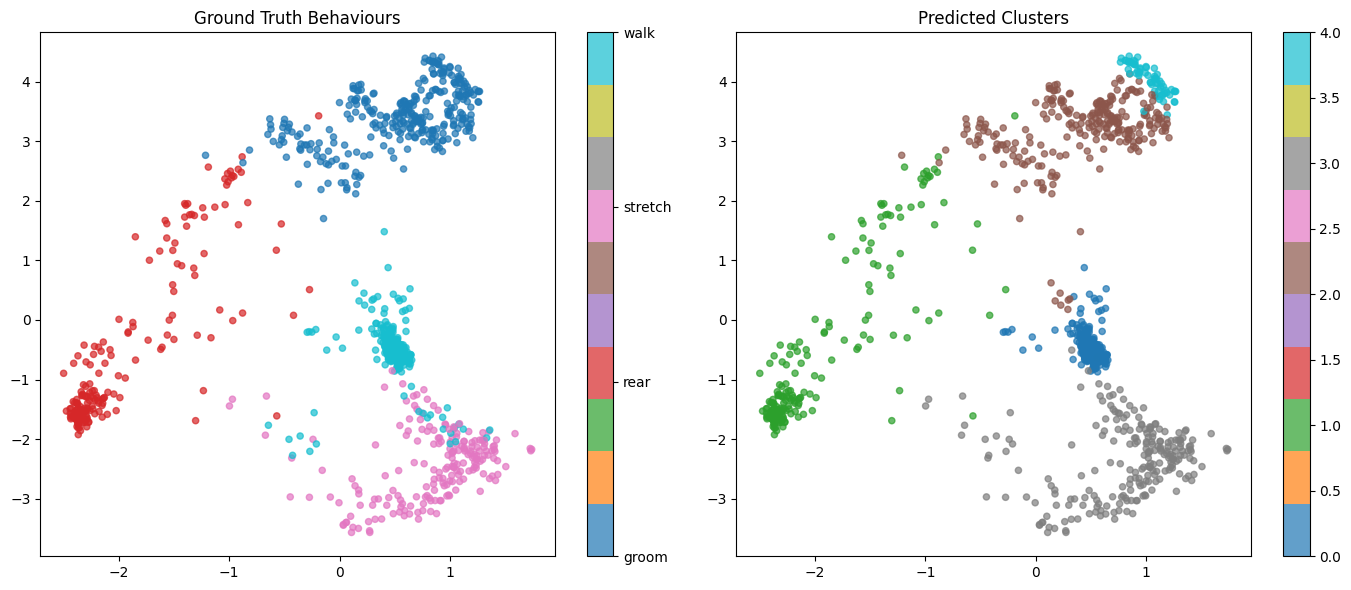

Upper bound ARI (perfect clustering): 1.000
ARI on pure windows only: 0.872


In [11]:
# ── Check 1: how pure are your windows? ───────────────────
# if this is low, transition detection is the bottleneck
print(f"Pure windows: {np.mean(pure_windows):.1%}")
# if < 70%, fix transition detection before anything else

# ── Check 2: does the latent space have structure? ─────────
# plot GT labels on the latent space
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(results['latents'][:, 0], results['latents'][:, 1],
                           c=gt_numeric, cmap='tab10', alpha=0.7, s=20)
axes[0].set_title("Ground Truth Behaviours")
plt.colorbar(scatter, ax=axes[0],
             ticks=range(len(behaviour_names))).set_ticklabels(behaviour_names)

scatter2 = axes[1].scatter(results['latents'][:, 0], results['latents'][:, 1],
                            c=results['cluster_labels'], cmap='tab10', alpha=0.7, s=20)
axes[1].set_title("Predicted Clusters")
plt.colorbar(scatter2, ax=axes[1])
plt.tight_layout()
plt.show()
# if GT colours are jumbled → model isn't learning, fix preprocessing/training
# if GT colours show structure but clusters don't align → fix clustering

# ── Check 3: upper bound ARI if windows were perfect ───────
# assign each window its majority GT label as the prediction
# this tells you the maximum ARI your transition detector allows
from sklearn.metrics import adjusted_rand_score
upper_bound_ari = adjusted_rand_score(gt_numeric, gt_numeric)
print(f"Upper bound ARI (perfect clustering): {upper_bound_ari:.3f}")  # should be 1.0

# more useful — what ARI would you get if you clustered perfectly
# on only the pure windows?
pure_mask = np.array(pure_windows)
if pure_mask.sum() > 0:
    ari_pure = adjusted_rand_score(gt_numeric[pure_mask],
                                   results['cluster_labels'][pure_mask])
    print(f"ARI on pure windows only: {ari_pure:.3f}")

In [12]:
# ============================================================
# SAVE ALL RESULTS AND FIGURES TO ./results
# ============================================================
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.optimize import linear_sum_assignment

RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── 0. Save hyperparameter search log ─────────────────────────────────────
if 'search_log' in dir():
    with open(os.path.join(RESULTS_DIR, "hyperparameter_search.json"), "w") as f:
        json.dump({
            "objective": "maximize ARI",
            "max_iterations": 10,
            "percentile_range": [50, 100],
            "quantile_range": [0.05, 0.5],
            "search_log": search_log,
            "best_percentile": results.get('_percentile', None),
            "best_quantile": results.get('_quantile', None),
        }, f, indent=2)
    print("Saved hyperparameter search log.")

# ── 1. Save model weights ─────────────────────────────────────────────────
torch.save(results['model_stage1'].state_dict(), os.path.join(RESULTS_DIR, "model_stage1.pth"))
torch.save(results['model'].state_dict(), os.path.join(RESULTS_DIR, "model_stage2.pth"))
print("Saved model weights.")

# ── 2. Save numerical results ─────────────────────────────────────────────
np.save(os.path.join(RESULTS_DIR, "latents.npy"), results['latents'])
np.save(os.path.join(RESULTS_DIR, "latents_2d.npy"), results['latents_2d'])
np.save(os.path.join(RESULTS_DIR, "cluster_labels.npy"), results['cluster_labels'])
np.save(os.path.join(RESULTS_DIR, "transition_frames.npy"), results['transition_frames'])
np.save(os.path.join(RESULTS_DIR, "losses.npy"), results['losses'])
np.save(os.path.join(RESULTS_DIR, "positions.npy"), results['positions'])
np.save(os.path.join(RESULTS_DIR, "smoothed_losses.npy"), results['smoothed_losses'])
np.save(os.path.join(RESULTS_DIR, "lossgraph_stage1.npy"), np.array(results['lossgraph_stage1']))
np.save(os.path.join(RESULTS_DIR, "lossgraph_stage2.npy"), np.array(results['lossgraph_stage2']))
print("Saved numerical results.")

# ── 3. Save window metadata ───────────────────────────────────────────────
window_lengths = [len(w) for w in results['windows']]
window_meta = {
    "n_windows": len(results['windows']),
    "min_length": int(min(window_lengths)),
    "max_length": int(max(window_lengths)),
    "mean_length": float(np.mean(window_lengths)),
    "n_transitions": int(len(results['transition_frames'])),
    "n_clusters": int(len(np.unique(results['cluster_labels']))),
    "best_percentile": results.get('_percentile', None),
    "best_quantile": results.get('_quantile', None),
}
with open(os.path.join(RESULTS_DIR, "window_meta.json"), "w") as f:
    json.dump(window_meta, f, indent=2)
print("Saved window metadata.")

# ── 4. Save clustering metrics ────────────────────────────────────────────
behaviour_names = np.unique(gt_window_labels)
beh_to_idx = {b: i for i, b in enumerate(behaviour_names)}
gt_numeric = np.array([beh_to_idx[b] for b in gt_window_labels])
cluster_ids = np.unique(results['cluster_labels'])
cm = np.zeros((len(behaviour_names), len(cluster_ids)), dtype=int)
for gt, pred in zip(gt_window_labels, results['cluster_labels']):
    cm[beh_to_idx[gt], pred] += 1

ari = adjusted_rand_score(gt_numeric, results['cluster_labels'])
nmi = normalized_mutual_info_score(gt_numeric, results['cluster_labels'])
purity = np.sum(np.max(cm, axis=0)) / np.sum(cm)

row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {}
for r, c in zip(row_ind, col_ind):
    total = int(cm[:, c].sum())
    correct = int(cm[r, c])
    mapping[f"Cluster {c}"] = {
        "behaviour": str(behaviour_names[r]),
        "correct": correct,
        "total": total,
        "accuracy": correct / total if total > 0 else 0.0,
    }

metrics = {
    "ARI": round(float(ari), 4),
    "NMI": round(float(nmi), 4),
    "Purity": round(float(purity), 4),
    "cluster_behaviour_mapping": mapping,
    "confusion_matrix": cm.tolist(),
    "behaviour_names": behaviour_names.tolist(),
    "cluster_ids": cluster_ids.tolist(),
}
with open(os.path.join(RESULTS_DIR, "clustering_metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved clustering metrics.")

# ── 5. Save all figures ───────────────────────────────────────────────────

# 5a. Training loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(results['lossgraph_stage1'], 'b-', linewidth=1.5)
axes[0].set_title("Stage 1: Fixed Windows Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(results['lossgraph_stage2'], 'r-', linewidth=1.5)
axes[1].set_title("Stage 2: Variable Windows Training Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "training_loss.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved training_loss.png")

# 5b. Reconstruction loss signal and transitions
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results['positions'], results['losses'], 'b.', markersize=2, alpha=0.3, label="Raw loss")
ax.plot(results['positions'], results['smoothed_losses'], 'r-', linewidth=1.5, label="Smoothed loss")
for tf in results['transition_frames']:
    ax.axvline(x=tf, color='g', alpha=0.15, linewidth=0.5)
ax.set_title("Reconstruction Loss & Detected Transitions")
ax.set_xlabel("Frame")
ax.set_ylabel("MSE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "reconstruction_loss.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved reconstruction_loss.png")

# 5c. Latent space scatter (no labels)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(results['latents'][:, 0], results['latents'][:, 1], s=10, alpha=0.6)
ax.set_title("Latent Space")
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "latent_space.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved latent_space.png")

# 5d. Clustered latent space
n_clusters = len(np.unique(results['cluster_labels']))
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(results['latents'][:, 0], results['latents'][:, 1],
                     c=results['cluster_labels'], cmap='tab10', s=15, alpha=0.8)
ax.set_title(f"Clusters (n={n_clusters})\n"
             f"percentile={results.get('_percentile', 'N/A'):.1f}, quantile={results.get('_quantile', 'N/A'):.3f}")
plt.colorbar(scatter, ax=ax, label='Cluster')
ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "clustered_latent_space.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved clustered_latent_space.png")

# 5e. Confusion matrix
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
            xticklabels=[f'Cluster {i}' for i in cluster_ids],
            yticklabels=behaviour_names)
ax.set_xlabel("Predicted Cluster")
ax.set_ylabel("Ground Truth Behaviour")
ax.set_title(f"Confusion Matrix (ARI={ari:.3f}, NMI={nmi:.3f}, Purity={purity:.3f})\n"
             f"percentile={results.get('_percentile', 'N/A'):.1f}, quantile={results.get('_quantile', 'N/A'):.3f}")
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved confusion_matrix.png")

# 5f. Diagnostic: GT vs Predicted on latent space
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
scatter = axes[0].scatter(results['latents'][:, 0], results['latents'][:, 1],
                          c=gt_numeric, cmap='tab10', alpha=0.7, s=20)
axes[0].set_title("Ground Truth Behaviours")
plt.colorbar(scatter, ax=axes[0],
             ticks=range(len(behaviour_names))).set_ticklabels(behaviour_names)

scatter2 = axes[1].scatter(results['latents'][:, 0], results['latents'][:, 1],
                           c=results['cluster_labels'], cmap='tab10', alpha=0.7, s=20)
axes[1].set_title("Predicted Clusters")
plt.colorbar(scatter2, ax=axes[1])
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "diagnostic_gt_vs_predicted.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved diagnostic_gt_vs_predicted.png")

# 5g. Pure windows diagnostic bar chart
pure_mask = np.array(pure_windows)
ari_pure = adjusted_rand_score(gt_numeric[pure_mask], results['cluster_labels'][pure_mask]) if pure_mask.sum() > 0 else 0
fig, ax = plt.subplots(figsize=(8, 5))
categories = ["All Windows", "Pure Windows Only"]
ari_values = [ari, ari_pure]
nmi_values = [nmi, nmi]
x = np.arange(len(categories))
width = 0.35
bars1 = ax.bar(x - width/2, ari_values, width, label='ARI', color='steelblue')
bars2 = ax.bar(x + width/2, nmi_values, width, label='NMI', color='coral')
ax.set_ylabel("Score")
ax.set_title("Clustering Performance: All vs Pure Windows")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()
ax.set_ylim(0, 1.1)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=10)
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, "performance_comparison.png"), dpi=150, bbox_inches="tight")
plt.close(fig)
print("Saved performance_comparison.png")

print(f"\nAll results saved to ./{RESULTS_DIR}/")

Saved hyperparameter search log.
Saved model weights.
Saved numerical results.
Saved window metadata.
Saved clustering metrics.
Saved training_loss.png
Saved reconstruction_loss.png
Saved latent_space.png
Saved clustered_latent_space.png
Saved confusion_matrix.png
Saved diagnostic_gt_vs_predicted.png
Saved performance_comparison.png

All results saved to ./results/
